<a href="https://colab.research.google.com/github/solayman-cs/ML/blob/master/MeanTeacher_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading series...

=== Train Teacher (1-step ahead, label-smoothed CE) ===
[Teacher] Epoch 01/80  TrainCE_smooth=3.2436  ValCE_smooth=2.7749
[Teacher] Epoch 02/80  TrainCE_smooth=2.8455  ValCE_smooth=2.6812
[Teacher] Epoch 03/80  TrainCE_smooth=2.8027  ValCE_smooth=2.6905
[Teacher] Epoch 04/80  TrainCE_smooth=2.7978  ValCE_smooth=2.6824
[Teacher] Epoch 05/80  TrainCE_smooth=2.7917  ValCE_smooth=2.6657
[Teacher] Epoch 06/80  TrainCE_smooth=2.7749  ValCE_smooth=2.6796
[Teacher] Epoch 07/80  TrainCE_smooth=2.7350  ValCE_smooth=2.6061
[Teacher] Epoch 08/80  TrainCE_smooth=2.5727  ValCE_smooth=2.4542
[Teacher] Epoch 09/80  TrainCE_smooth=2.4296  ValCE_smooth=2.3397
[Teacher] Epoch 10/80  TrainCE_smooth=2.3065  ValCE_smooth=2.2044
[Teacher] Epoch 11/80  TrainCE_smooth=2.2300  ValCE_smooth=2.1424
[Teacher] Epoch 12/80  TrainCE_smooth=2.2253  ValCE_smooth=2.2303
[Teacher] Epoch 13/80  TrainCE_smooth=2.1939  ValCE_smooth=2.1662
[Teacher] Epoch 14/80  TrainCE_smooth=2.1480  ValCE_smooth=2.0991
[

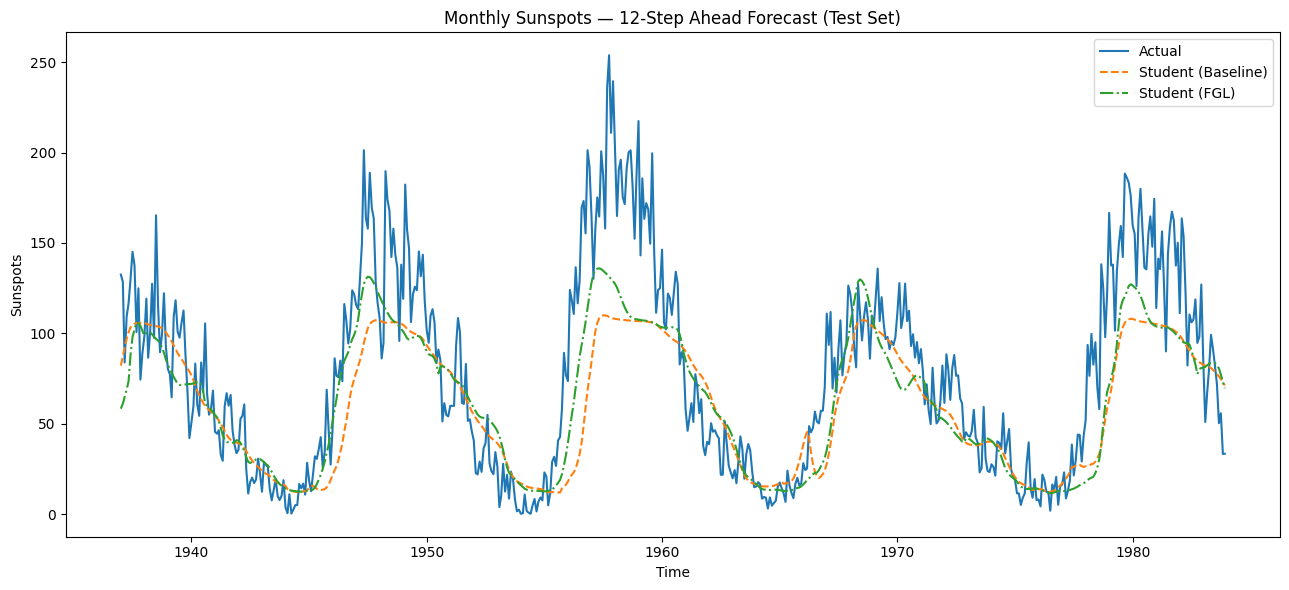

Saved: fgl_sunspots_test_predictions.csv


In [12]:


import math
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from typing import Tuple

# =========================
# Hyperparameters
# =========================
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv"  # Month,Sunspots
VALUE_COL = "Sunspots"
TIME_COL = "Month"

WINDOW = 60            # LSTM input length
HORIZON = 12           # months ahead to predict (student)
TEACHER_H = 1          # teacher horizon
BINS = 30              # discretization bins
BATCH_SIZE = 128
EPOCHS_TEACHER = 80
EPOCHS_STUDENT = 100
LR = 8e-4
WEIGHT_DECAY = 1e-4
TAU = 1.2              # distillation temperature
VAL_SPLIT = 0.1        # plenty of data; smaller val split
TEST_RATIO = 0.2
SEED = 42
PATIENCE = 10          # early stopping

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# =========================
# Utilities
# =========================
def load_series(url: str, time_col: str, value_col: str) -> pd.Series:
    df = pd.read_csv(url)

    if time_col not in df.columns:

        for c in df.columns:
            if c.lower() == time_col.lower():
                time_col = c
            if c.lower() == value_col.lower():
                value_col = c
    s = df[value_col].astype(float)
    s.index = pd.to_datetime(df[time_col])
    return s

def minmax_scale(train_values, values):
    vmin, vmax = float(np.min(train_values)), float(np.max(train_values))
    scaled = (values - vmin) / (vmax - vmin + 1e-12)
    return scaled, vmin, vmax

def inverse_minmax_scale(scaled, vmin, vmax):
    return scaled * (vmax - vmin) + vmin

def make_bins(vmin: float, vmax: float, B: int):
    edges = np.linspace(vmin, vmax, B + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return edges, centers

def digitize_values(values: np.ndarray, edges: np.ndarray) -> np.ndarray:
    bins = np.digitize(values, edges[1:-1], right=False)
    return np.clip(bins, 0, len(edges) - 2)

def windowed_pairs_multi(series_2d: np.ndarray, window: int, horizon: int):
    """series_2d: [N, D]; returns X:[M, window, D], y:[M] (value channel at t+h)"""
    X, y = [], []
    N = len(series_2d)
    for t in range(window - 1, N - horizon):
        X.append(series_2d[t - window + 1: t + 1, :])
        y.append(series_2d[t + horizon, 0])  # predict scaled value (col 0) at t+H
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def split_train_val(X, y, y_bins, val_split=0.2):
    N = len(X)
    n_val = int(N * val_split)
    if n_val == 0:
        return (X, y, y_bins), (X[-1:], y[-1:], y_bins[-1:])
    return (X[:-n_val], y[:-n_val], y_bins[:-n_val]), (X[-n_val:], y[-n_val:], y_bins[-n_val:])

# =========================
# Datasets
# =========================
class SeqDataset(Dataset):
    def __init__(self, X, y, y_bins, centers):
        self.X = torch.from_numpy(X)             # [N, L, D]
        self.y = torch.from_numpy(y).float()     # [N]
        self.y_bins = torch.from_numpy(y_bins).long()
        self.centers = torch.from_numpy(centers).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.y_bins[i]

class PairedDataset(Dataset):
    """Yields ((x_student, y, yb), (x_teacher, y, yb)) aligned on the same target time."""
    def __init__(self, ds_s: SeqDataset, ds_t: SeqDataset):
        assert len(ds_s) == len(ds_t)
        self.ds_s = ds_s
        self.ds_t = ds_t
    def __len__(self): return len(self.ds_s)
    def __getitem__(self, i):
        return self.ds_s[i], self.ds_t[i]

# =========================
# Model
# =========================
class LSTMHead(nn.Module):
    def __init__(self, input_dim=3, hidden=128, layers=2, out_dim=30, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden, num_layers=layers,
                            dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden, out_dim)
    def forward(self, x):
        # x: [B,L,D]
        h, _ = self.lstm(x)
        return self.fc(h[:, -1, :])  # [B,C]

# =========================
# Losses
# =========================
class SmoothCE(nn.Module):
    def __init__(self, smoothing=0.05):
        super().__init__()
        self.smoothing = smoothing
    def forward(self, logits, target, num_classes):
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (num_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        log_probs = torch.log_softmax(logits, dim=1)
        return -(true_dist * log_probs).sum(dim=1).mean()

def fgl_loss_scheduled(student_logits, teacher_logits, hard_targets, epoch, total_epochs, tau=1.2):
    """CE with hard labels + KL(teacher||student) with a ramped KL weight (max 0.1)."""
    # ramp KL from 0 to 0.1 over the first half of training
    kl_w = 0.1 * min(1.0, epoch / (0.5 * total_epochs))
    ce_w = 1.0 - kl_w
    ce = nn.CrossEntropyLoss()(student_logits, hard_targets)
    log_p_s = nn.LogSoftmax(dim=1)(student_logits / tau)
    p_t = nn.Softmax(dim=1)(teacher_logits / tau).detach()
    kld = nn.KLDivLoss(reduction="batchmean")(log_p_s, p_t) * (tau ** 2)
    return ce_w * ce + kl_w * kld, ce.item(), kld.item(), ce_w, kl_w

# =========================
# Early Stopping
# =========================
class EarlyStopper:
    def __init__(self, patience=10, mode="min"):
        self.patience = patience
        self.best = None
        self.count = 0
        self.mode = mode
    def step(self, value):
        improved = False
        if self.best is None:
            improved = True
        else:
            if self.mode == "min":
                improved = value < self.best - 1e-8
            else:
                improved = value > self.best + 1e-8
        if improved:
            self.best = value
            self.count = 0
        else:
            self.count += 1
        return improved, self.count >= self.patience

# =========================
# Training loops
# =========================
def train_teacher(model, loader, val_loader, epochs=80, lr=8e-4, weight_decay=1e-4,
                  num_classes=BINS, device=DEVICE, smoothing=0.05, patience=PATIENCE):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    smooth_ce = SmoothCE(smoothing=smoothing)
    stopper = EarlyStopper(patience=patience, mode="min")
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        tr_loss = 0.0
        for xb, _, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = smooth_ce(logits, yb, num_classes)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= len(loader.dataset)

        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for xb, _, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = smooth_ce(logits, yb, num_classes)
                val_loss += loss.item() * len(xb)
            val_loss /= len(val_loader.dataset)

        print(f"[Teacher] Epoch {ep:02d}/{epochs}  TrainCE_smooth={tr_loss:.4f}  ValCE_smooth={val_loss:.4f}")

        improved, should_stop = stopper.step(val_loss)
        if improved:
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if should_stop:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def train_student_baseline(student, loader, val_loader, epochs=100, lr=8e-4, weight_decay=1e-4,
                           device=DEVICE, patience=PATIENCE):
    student.to(device)
    opt = torch.optim.Adam(student.parameters(), lr=lr, weight_decay=weight_decay)
    ce_loss = nn.CrossEntropyLoss()
    stopper = EarlyStopper(patience=patience, mode="min")
    best_state = None

    for ep in range(1, epochs + 1):
        student.train()
        tr_loss = 0.0
        for xb, _, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = student(xb)
            loss = ce_loss(logits, yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= len(loader.dataset)

        student.eval()
        with torch.no_grad():
            val_loss = 0.0
            for xb, _, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = student(xb)
                loss = ce_loss(logits, yb)
                val_loss += loss.item() * len(xb)
            val_loss /= len(val_loader.dataset)

        print(f"[Student-Base] Epoch {ep:02d}/{epochs}  TrainCE={tr_loss:.4f}  ValCE={val_loss:.4f}")

        improved, should_stop = stopper.step(val_loss)
        if improved:
            best_state = {k: v.cpu().clone() for k, v in student.state_dict().items()}
        if should_stop:
            break

    if best_state is not None:
        student.load_state_dict(best_state)
    return student

def train_student_fgl(student, teacher, paired_loader, paired_val_loader, epochs=100, lr=8e-4,
                      weight_decay=1e-4, device=DEVICE, patience=PATIENCE, tau=TAU):
    student.to(device)
    teacher.to(device).eval()
    for p in teacher.parameters():
        p.requires_grad_(False)
    opt = torch.optim.Adam(student.parameters(), lr=lr, weight_decay=weight_decay)
    stopper = EarlyStopper(patience=patience, mode="min")
    best_state = None

    for ep in range(1, epochs + 1):
        student.train()
        tr_loss = tr_ce = tr_kl = 0.0
        for (x_s, _, yb), (x_t, _, _) in paired_loader:
            x_s, yb = x_s.to(device), yb.to(device)
            x_t = x_t.to(device)

            opt.zero_grad()
            s_logits = student(x_s)
            t_logits = teacher(x_t)
            loss, ce_part, kl_part, ce_w, kl_w = fgl_loss_scheduled(
                s_logits, t_logits, yb, epoch=ep, total_epochs=epochs, tau=tau
            )
            loss.backward()
            opt.step()

            bs = len(x_s)
            tr_loss += loss.item() * bs
            tr_ce   += ce_part * bs
            tr_kl   += kl_part * bs

        N = len(paired_loader.dataset)
        tr_loss /= N; tr_ce /= N; tr_kl /= N

        # validation
        student.eval()
        with torch.no_grad():
            val_loss = 0.0
            for (x_s, _, yb), (x_t, _, _) in paired_val_loader:
                x_s, yb = x_s.to(device), yb.to(device)
                x_t = x_t.to(device)
                s_logits = student(x_s)
                t_logits = teacher(x_t)
                loss, _, _, _, _ = fgl_loss_scheduled(
                    s_logits, t_logits, yb, epoch=ep, total_epochs=epochs, tau=tau
                )
                val_loss += loss.item() * len(x_s)
            val_loss /= len(paired_val_loader.dataset)

        print(f"[Student-FGL] Epoch {ep:02d}/{epochs}  Train={tr_loss:.4f} (CE={tr_ce:.4f}, KL={tr_kl:.4f})  Val={val_loss:.4f}")

        improved, should_stop = stopper.step(val_loss)
        if improved:
            best_state = {k: v.cpu().clone() for k, v in student.state_dict().items()}
        if should_stop:
            break

    if best_state is not None:
        student.load_state_dict(best_state)
    return student

# =========================
# Evaluation helpers
# =========================
def predict_expectation(model, loader, centers, device=DEVICE):
    """Return y_true_scaled, y_pred_scaled (expectation over bin centers)."""
    model.eval()
    centers_t = torch.tensor(centers, dtype=torch.float32, device=device)
    y_true_scaled, y_pred_scaled = [], []
    with torch.no_grad():
        for xb, y_real_scaled, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)
            exp_scaled = torch.sum(probs * centers_t[None, :], dim=1)
            y_true_scaled.append(y_real_scaled.numpy())
            y_pred_scaled.append(exp_scaled.cpu().numpy())
    y_true_scaled = np.concatenate(y_true_scaled)
    y_pred_scaled = np.concatenate(y_pred_scaled)
    return y_true_scaled, y_pred_scaled

def mse(a, b):
    return float(np.mean((a - b) ** 2))

# =========================
# Main
# =========================
def main():
    print("Loading series...")
    s = load_series(URL, TIME_COL, VALUE_COL)
    values = s.values.astype(np.float32)
    N = len(values)

    # Train/Test split (last TEST_RATIO as test)
    n_test = int(N * TEST_RATIO)
    train_vals = values[:-n_test]

    # Scale by train-only statistics
    scaled_all, vmin, vmax = minmax_scale(train_vals, values)

    # Month-of-year features
    month = s.index.month.values.astype(np.float32)
    m_sin = np.sin(2*np.pi*month/12.0)
    m_cos = np.cos(2*np.pi*month/12.0)

    # Feature matrix: value(scaled), sin, cos
    feat_all = np.stack([scaled_all, m_sin, m_cos], axis=1).astype(np.float32)  # [N,3]

    # Student samples: WINDOW -> value at t+HORIZON
    Xs_all, ys_all = windowed_pairs_multi(feat_all, WINDOW, HORIZON)
    original_indices = np.arange(WINDOW - 1, WINDOW - 1 + len(ys_all))
    target_positions = original_indices + HORIZON

    # Define test mask by target time
    test_mask = target_positions >= (N - n_test)
    train_mask = ~test_mask

    # Teacher samples (1 step)
    Xt_all, yt_all = windowed_pairs_multi(feat_all, WINDOW, TEACHER_H)   # y is value at t+1 (scaled)

    # Align teacher window to predict the *same* target time as student's t+H:
    jt = original_indices + HORIZON - WINDOW
    valid = (jt >= 0) & (jt < len(Xt_all))

    # Filter for valid alignments
    Xs_all = Xs_all[valid]; ys_all = ys_all[valid]
    Xt_all = Xt_all[jt[valid]]
    original_indices = original_indices[valid]
    target_positions = target_positions[valid]
    test_mask = target_positions >= (N - n_test)
    train_mask = ~test_mask

    # Build bins from TRAIN targets only (scaled)
    ytrain_min = float(np.min(ys_all[train_mask]))
    ytrain_max = float(np.max(ys_all[train_mask]))
    edges, centers = make_bins(ytrain_min, ytrain_max, BINS)
    yb_all = digitize_values(ys_all, edges)

    # Train/Val/Test splits for student and teacher
    Xs_tr, ys_tr, yb_tr = Xs_all[train_mask], ys_all[train_mask], yb_all[train_mask]
    Xs_te, ys_te, yb_te = Xs_all[test_mask],  ys_all[test_mask],  yb_all[test_mask]
    Xt_tr, yt_tr = Xt_all[train_mask], ys_all[train_mask]   # teacher target equals student's target at same time
    Xt_te, yt_te = Xt_all[test_mask],  ys_all[test_mask]

    (Xs_tr_tr, ys_s_tr, yb_s_tr), (Xs_tr_val, ys_s_val, yb_s_val) = split_train_val(Xs_tr, ys_tr, yb_tr, VAL_SPLIT)
    (Xt_tr_tr, yt_t_tr, yb_t_tr), (Xt_tr_val, yt_t_val, yb_t_val) = split_train_val(Xt_tr, yt_tr, yb_tr, VAL_SPLIT)

    # Datasets/Loaders
    ds_student_tr = SeqDataset(Xs_tr_tr, ys_s_tr, yb_s_tr, centers)
    ds_student_val = SeqDataset(Xs_tr_val, ys_s_val, yb_s_val, centers)
    ds_student_te = SeqDataset(Xs_te, ys_te, yb_te, centers)

    ds_teacher_tr = SeqDataset(Xt_tr_tr, yt_t_tr, yb_t_tr, centers)
    ds_teacher_val = SeqDataset(Xt_tr_val, yt_t_val, yb_t_val, centers)
    ds_teacher_te = SeqDataset(Xt_te, yt_te, yb_te, centers)

    dl_student_tr = DataLoader(ds_student_tr, batch_size=BATCH_SIZE, shuffle=True)
    dl_student_val = DataLoader(ds_student_val, batch_size=BATCH_SIZE, shuffle=False)
    dl_student_te = DataLoader(ds_student_te, batch_size=BATCH_SIZE, shuffle=False)

    dl_teacher_tr = DataLoader(ds_teacher_tr, batch_size=BATCH_SIZE, shuffle=True)
    dl_teacher_val = DataLoader(ds_teacher_val, batch_size=BATCH_SIZE, shuffle=False)

    paired_tr = PairedDataset(ds_student_tr, ds_teacher_tr)
    paired_val = PairedDataset(ds_student_val, ds_teacher_val)
    dl_paired_tr = DataLoader(paired_tr, batch_size=BATCH_SIZE, shuffle=True)
    dl_paired_val = DataLoader(paired_val, batch_size=BATCH_SIZE, shuffle=False)

    # Models
    teacher = LSTMHead(input_dim=3, hidden=128, layers=2, out_dim=BINS, dropout=0.3)
    student_base = LSTMHead(input_dim=3, hidden=128, layers=2, out_dim=BINS, dropout=0.3)
    student_fgl  = LSTMHead(input_dim=3, hidden=128, layers=2, out_dim=BINS, dropout=0.3)

    # ===== Train Teacher =====
    print("\n=== Train Teacher (1-step ahead, label-smoothed CE) ===")
    teacher = train_teacher(
        teacher, dl_teacher_tr, dl_teacher_val,
        epochs=EPOCHS_TEACHER, lr=LR, weight_decay=WEIGHT_DECAY,
        num_classes=BINS, device=DEVICE, smoothing=0.05, patience=PATIENCE
    )

    # ===== Train Student Baseline =====
    print("\n=== Train Student (baseline, H-step ahead) ===")
    student_base = train_student_baseline(
        student_base, dl_student_tr, dl_student_val,
        epochs=EPOCHS_STUDENT, lr=LR, weight_decay=WEIGHT_DECAY,
        device=DEVICE, patience=PATIENCE
    )

    # ===== Train Student FGL =====
    print("\n=== Train Student (FGL with scheduled KL from teacher) ===")
    student_fgl = train_student_fgl(
        student_fgl, teacher, dl_paired_tr, dl_paired_val,
        epochs=EPOCHS_STUDENT, lr=LR, weight_decay=WEIGHT_DECAY,
        device=DEVICE, patience=PATIENCE, tau=TAU
    )

    # ===== Evaluate (scaled and original) =====
    print("\n=== Evaluate on TEST ===")
    y_true_s_base, y_pred_s_base = predict_expectation(student_base, dl_student_te, centers, device=DEVICE)
    y_true_s_fgl,  y_pred_s_fgl  = predict_expectation(student_fgl,  dl_student_te, centers, device=DEVICE)

    mse_scaled_base = mse(y_true_s_base, y_pred_s_base)
    mse_scaled_fgl  = mse(y_true_s_fgl,  y_pred_s_fgl)
    print(f"Baseline Student MSE (scaled): {mse_scaled_base:.6f}")
    print(f"FGL Student     MSE (scaled): {mse_scaled_fgl:.6f}")

    # original units
    y_true_orig = inverse_minmax_scale(y_true_s_base, vmin, vmax)
    y_base_orig = inverse_minmax_scale(y_pred_s_base, vmin, vmax)
    y_fgl_orig  = inverse_minmax_scale(y_pred_s_fgl,  vmin, vmax)

    mse_orig_base = mse(y_true_orig, y_base_orig)
    mse_orig_fgl  = mse(y_true_orig, y_fgl_orig)
    print(f"Baseline Student MSE (original units): {mse_orig_base:.3f}")
    print(f"FGL Student     MSE (original units): {mse_orig_fgl:.3f}")

    # ===== Plot (test set) =====
    test_target_idx = target_positions[test_mask]
    time_index_test = s.index[test_target_idx]

    plt.figure(figsize=(13, 6))
    plt.plot(time_index_test, y_true_orig, label="Actual")
    plt.plot(time_index_test, y_base_orig, label="Student (Baseline)", linestyle="--")
    plt.plot(time_index_test, y_fgl_orig,  label="Student (FGL)", linestyle="-.")
    plt.title(f"Monthly Sunspots — {HORIZON}-Step Ahead Forecast (Test Set)")
    plt.xlabel("Time")
    plt.ylabel("Sunspots")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ===== Save CSV (test predictions) =====
    out = pd.DataFrame({
        "time": time_index_test,
        "actual": y_true_orig,
        "baseline": y_base_orig,
        "fgl": y_fgl_orig
    }).set_index("time")
    out.to_csv("fgl_sunspots_test_predictions.csv")
    print("Saved: fgl_sunspots_test_predictions.csv")

if __name__ == "__main__":
    main()
